### **imports**

In [ ]:
import xarray as xr
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **loading in data and data prep**

##### **loading in .nc files**

loading in .nc files, extracting the integrated gradient dimension, averaging across result batches and long/lat to give variable importance values for each unique year combo and variable

In [ ]:
# getting directory for the result batches nc files 
parent_dir = Path.cwd() / "climate_experiments" 

# initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
folder_file_counts = {}

# going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
for run_folder in sorted(parent_dir.glob("result_batches*")):
    # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
    if run_folder.is_dir():
        # turning all the nc files in that folder into a list 
        nc_files = list(run_folder.glob("*.nc"))
        # if there are actually files in the folder
        if nc_files: 
            # count number of files in the folder and store that in the dictionary
            folder_file_counts[run_folder] = len(nc_files)

# error handling if all the folders are empty 
if not folder_file_counts:
    raise ValueError("no nc files in the folder!")


# finding max number of file counts (should be 56/57) -- complete run length
dynamic_expected = max(folder_file_counts.values())
print(f"max is {dynamic_expected} files")


# initializie list that will hold the arrays from every run 
all_runs_data = []

# going through each folder and looking at the files and the count of the files in the folder
for run_folder, count in folder_file_counts.items():

    # if the count of the files in the run folder does not equal 56/57 
    if count != dynamic_expected:
        print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
        # keep going to the next folder and don't save the folder that doesn't have right amount of files 
        continue
    
    # saving the nc files in chrnological order (via sorted)
    nc_files = sorted(list(run_folder.glob("*.nc")))
    # opening the files in the folder
        # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
        # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
    run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
    
    # extracting integrated gradient maps from nc file
    run_data = run_ds['ig_heatmaps'].values
        # run_data shape --> (56, 25, 144, 73, 7)
    # converting integrated gradient values into only positive values (to measure magnitude of importance), averaging across sample dimension (axis 1)
        # ig_heatmaps: (sample=25, lat=144, lon=73, feature=7)
    
    run_mean_samples = np.nanmean((run_data), axis=1) # changed to not absolute value
    # appending to list 
    all_runs_data.append(run_mean_samples)


# error handling if all folders do not have enough items 
if not all_runs_data:
    raise ValueError("none of the folders have enough nc files")

# stacking all the averaged heatmaps 
master_phi_matrix = np.stack(all_runs_data)
print(master_phi_matrix.shape) # (10, 56, 144, 73, 6)



max is 56 files
(10, 56, 144, 73, 6)


In [ ]:
print(np.max(master_phi_matrix[:, :, :, :, :]))

0.32974705


#### **making a df for yr combos and scenarios**

need unique yr comobos and scenarios split up in differentiating way for easy discernment in plotting code 

In [ ]:
# providing folder example that has correct number of items (56/57)
sample_folder = Path.cwd() / "climate_experiments" / "result_batchessophiekim_1" 
print(sample_folder)
# gets all the .nc files in chronological order 
nc_files = sorted(list(sample_folder.glob("*.nc")))

# initializing list
data = []


# looping through the .nc files to extract relevant info
for idx, filepath in enumerate(nc_files):
    # getting filename from .stem -- just gives 'res_ssp119_2015_2025' as filename
    filename = filepath.stem 
    # splitting so that _ splits each word into diff strings rather than one big one 
        # [res, ssp119, 2015, 2025]
    parts = filename.split('_')
    print(parts)
    print(filename)
    
    # extracting relevant info from the parts var
    scenario_id = parts[1]
    early_yr = int(parts[-2]) # second to last 
    late_yr = int(parts[-1]) # last 
    
    # compliling all the info tg 
    data.append({
        'combo_idx': idx,
        'scenario': scenario_id,
        'early': early_yr,
        'late': late_yr
    })


metadata_df = pd.DataFrame(data)

/Users/sophiekim/Desktop/2_research/MamalakisResearch/climate_experiments/result_batchessophiekim_1
['res', 'ssp119', '2015', '2025']
res_ssp119_2015_2025
['res', 'ssp119', '2015', '2035']
res_ssp119_2015_2035
['res', 'ssp119', '2015', '2045']
res_ssp119_2015_2045
['res', 'ssp119', '2015', '2055']
res_ssp119_2015_2055
['res', 'ssp119', '2015', '2065']
res_ssp119_2015_2065
['res', 'ssp119', '2015', '2075']
res_ssp119_2015_2075
['res', 'ssp119', '2015', '2085']
res_ssp119_2015_2085
['res', 'ssp119', '2025', '2035']
res_ssp119_2025_2035
['res', 'ssp119', '2025', '2045']
res_ssp119_2025_2045
['res', 'ssp119', '2025', '2055']
res_ssp119_2025_2055
['res', 'ssp119', '2025', '2065']
res_ssp119_2025_2065
['res', 'ssp119', '2025', '2075']
res_ssp119_2025_2075
['res', 'ssp119', '2025', '2085']
res_ssp119_2025_2085
['res', 'ssp119', '2035', '2045']
res_ssp119_2035_2045
['res', 'ssp119', '2035', '2055']
res_ssp119_2035_2055
['res', 'ssp119', '2035', '2065']
res_ssp119_2035_2065
['res', 'ssp119', '2

In [ ]:
metadata_df

,combo_idx,scenario,early,late
0,0,ssp119,2015,2025
1,1,ssp119,2015,2035
2,2,ssp119,2015,2045
3,3,ssp119,2015,2055
4,4,ssp119,2015,2065
5,5,ssp119,2015,2075
6,6,ssp119,2015,2085
7,7,ssp119,2025,2035
8,8,ssp119,2025,2045
9,9,ssp119,2025,2055


#### **defining variables**

for plotting purposes, to discern out the 7 layers in the array dimension

In [ ]:
# explicitly defining variables (order has to be exact as the .nc files)
climate_variables = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind"] # got order from the get_cnn_tensors file bc that is when X_data was prepped


# making dictionary so that legible var name appears in heatmaps
variable_dictionary = {
    "tas": "Mean Surface\nTemp",
    "tasmax": "Max Surface\nTemp",
    "tasmin": "Min Surface\nTemp",
    "pr": "Precipitation",
    "psl": "Sea Level\nPressure",
    "sfcWind": "Surface Wind\nSpeed"
}

# making new list 
    # making variables readable by replacing the original var for the value in variable dictionary via list comprehension
readable_variables = [variable_dictionary[var] for var in climate_variables]

print(readable_variables)

['Mean Surface\nTemp', 'Max Surface\nTemp', 'Min Surface\nTemp', 'Precipitation', 'Sea Level\nPressure', 'Surface Wind\nSpeed']


### **variable importance heatmaps**

all on one colorbar scale

In [ ]:

def var_importance_heatmaps_single_colorbar(phi_matrix, metadata_df, var_names, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 7)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # extracting out each dimension's length
    num_runs = phi_matrix.shape[0] # number of batch runs
    num_combos = phi_matrix.shape[1] # number of unique yr combos
    num_lon = phi_matrix.shape[2] # longitude
    num_lat = phi_matrix.shape[3] # latitude
    num_vars = phi_matrix.shape[4] # number of variables
    
    # calculating the sum of absolute value of the averaged ig heatmaps
        # basically total importance/attention that the CNN assigned across all 7 vars, grid points, yr combo, model runs
    total_phi_sum = np.nansum(np.abs(phi_matrix))
    # divide the sum by the product of multiplying all the dimensions' lengths (aka the number of data points)
        # gives the avg of importance at a single point -- global average baseline
    cbar_bound = total_phi_sum / (num_runs * num_combos * num_vars * num_lon * num_lat)
    
    # final averaging for plotting --> averaging across all the batches and long/lat 
        # first dimension = number of result batches, second = year combos, third = long, fourth = lat, fifth = variables
        # leaving behind the yr combos and variables 
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    

    # sorting by variable importance values 
        # argsort gives index position
        # sort gives actual values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
    # getting the importance rankings for most important, second most important, least important 
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), # most important (last)
        (sorted_indices[:, -2], sorted_values[:, -2]), # 2nd most important (2nd to last)
        (sorted_indices[:, 0],  sorted_values[:, 0])   # least important (first)
    ]
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(metadata_df['early'].unique()) | set(metadata_df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    


    # PLOTTING NOW
    # 1 row and 3 plots with specified fig size 
    fig, axes = plt.subplots(1, 3, figsize=(26, 11))
    

    # create axis on bottom for single global colorbar at bottom center
     # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.35, 0.06, 0.3, 0.025]) 
    
    # going through the rankings 
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
        # setting axes index for correct data to be in the corresponding importance heatmap
        ax = axes[i]
        
        
        # cell label formatting --> variable name and then next line is the variable importance value in scientific notation rounded to 2 dec places
            # list comprehension
                # zip puts the rank index and rank value tg (rank index is what variable it is and rank value is the IG importance value)
                # var_names[idx] pulls the variable name that corresponds with the rank index and then val for rank value 
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        # attaching the IG importance values and formatted text labels above to the metadata
        df = metadata_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        # pivot table to rows as early yrs and cols are late yrs 
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        # reindexing to make matrix include every early and late yr combos
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        # doing same thing as above but with the text labels 
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        # masking bottom left triangle shape of matrix since just repeats
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        
        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap='mako', 
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=0,           # colorbar min value 
            vmax=cbar_bound,  # colorbar max value
            ax=ax,
            annot_kws={"size": 8}, # shrinking text size in each cell so everything fits 
            cbar=(i == 0),        # only draw colorbar on very first loop iteration
            cbar_ax=cbar_ax if i == 0 else None,  # put coloarbar in center (location specified from cbar_ax)
            cbar_kws={"orientation": "horizontal"} if i == 0 else None 
        )
        
        
        # x axis lables on top 
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        # rotate x axis labels so diagonal 
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        # horizontal y axis labels 
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        

        ax.set_xlabel("Late 10-Year Period", fontsize=12, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=12, fontweight='bold')
        ax.set_title(rank_title, fontsize=16, fontweight='bold', pad=25)

    # colorbar formatting
    cbar_ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))  # making colorbar scientific notation 
    cbar_ax.tick_params(labelsize=11)
    for tick in cbar_ax.get_xticklabels():
        tick.set_fontweight('bold')
    cbar_ax.set_xlabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=10)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=22, fontweight='bold', y=1.02)
    
    # tight_layout rect leaves the bottom 12% of the figure empty so not overlapping colorbar at the bottom
    plt.tight_layout(rect=[0, 0.12, 1, 1]) 
    plt.show()

#### **plotting var importance heatmaps for both scenarios with one colorbar**

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_31627/3291906729.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


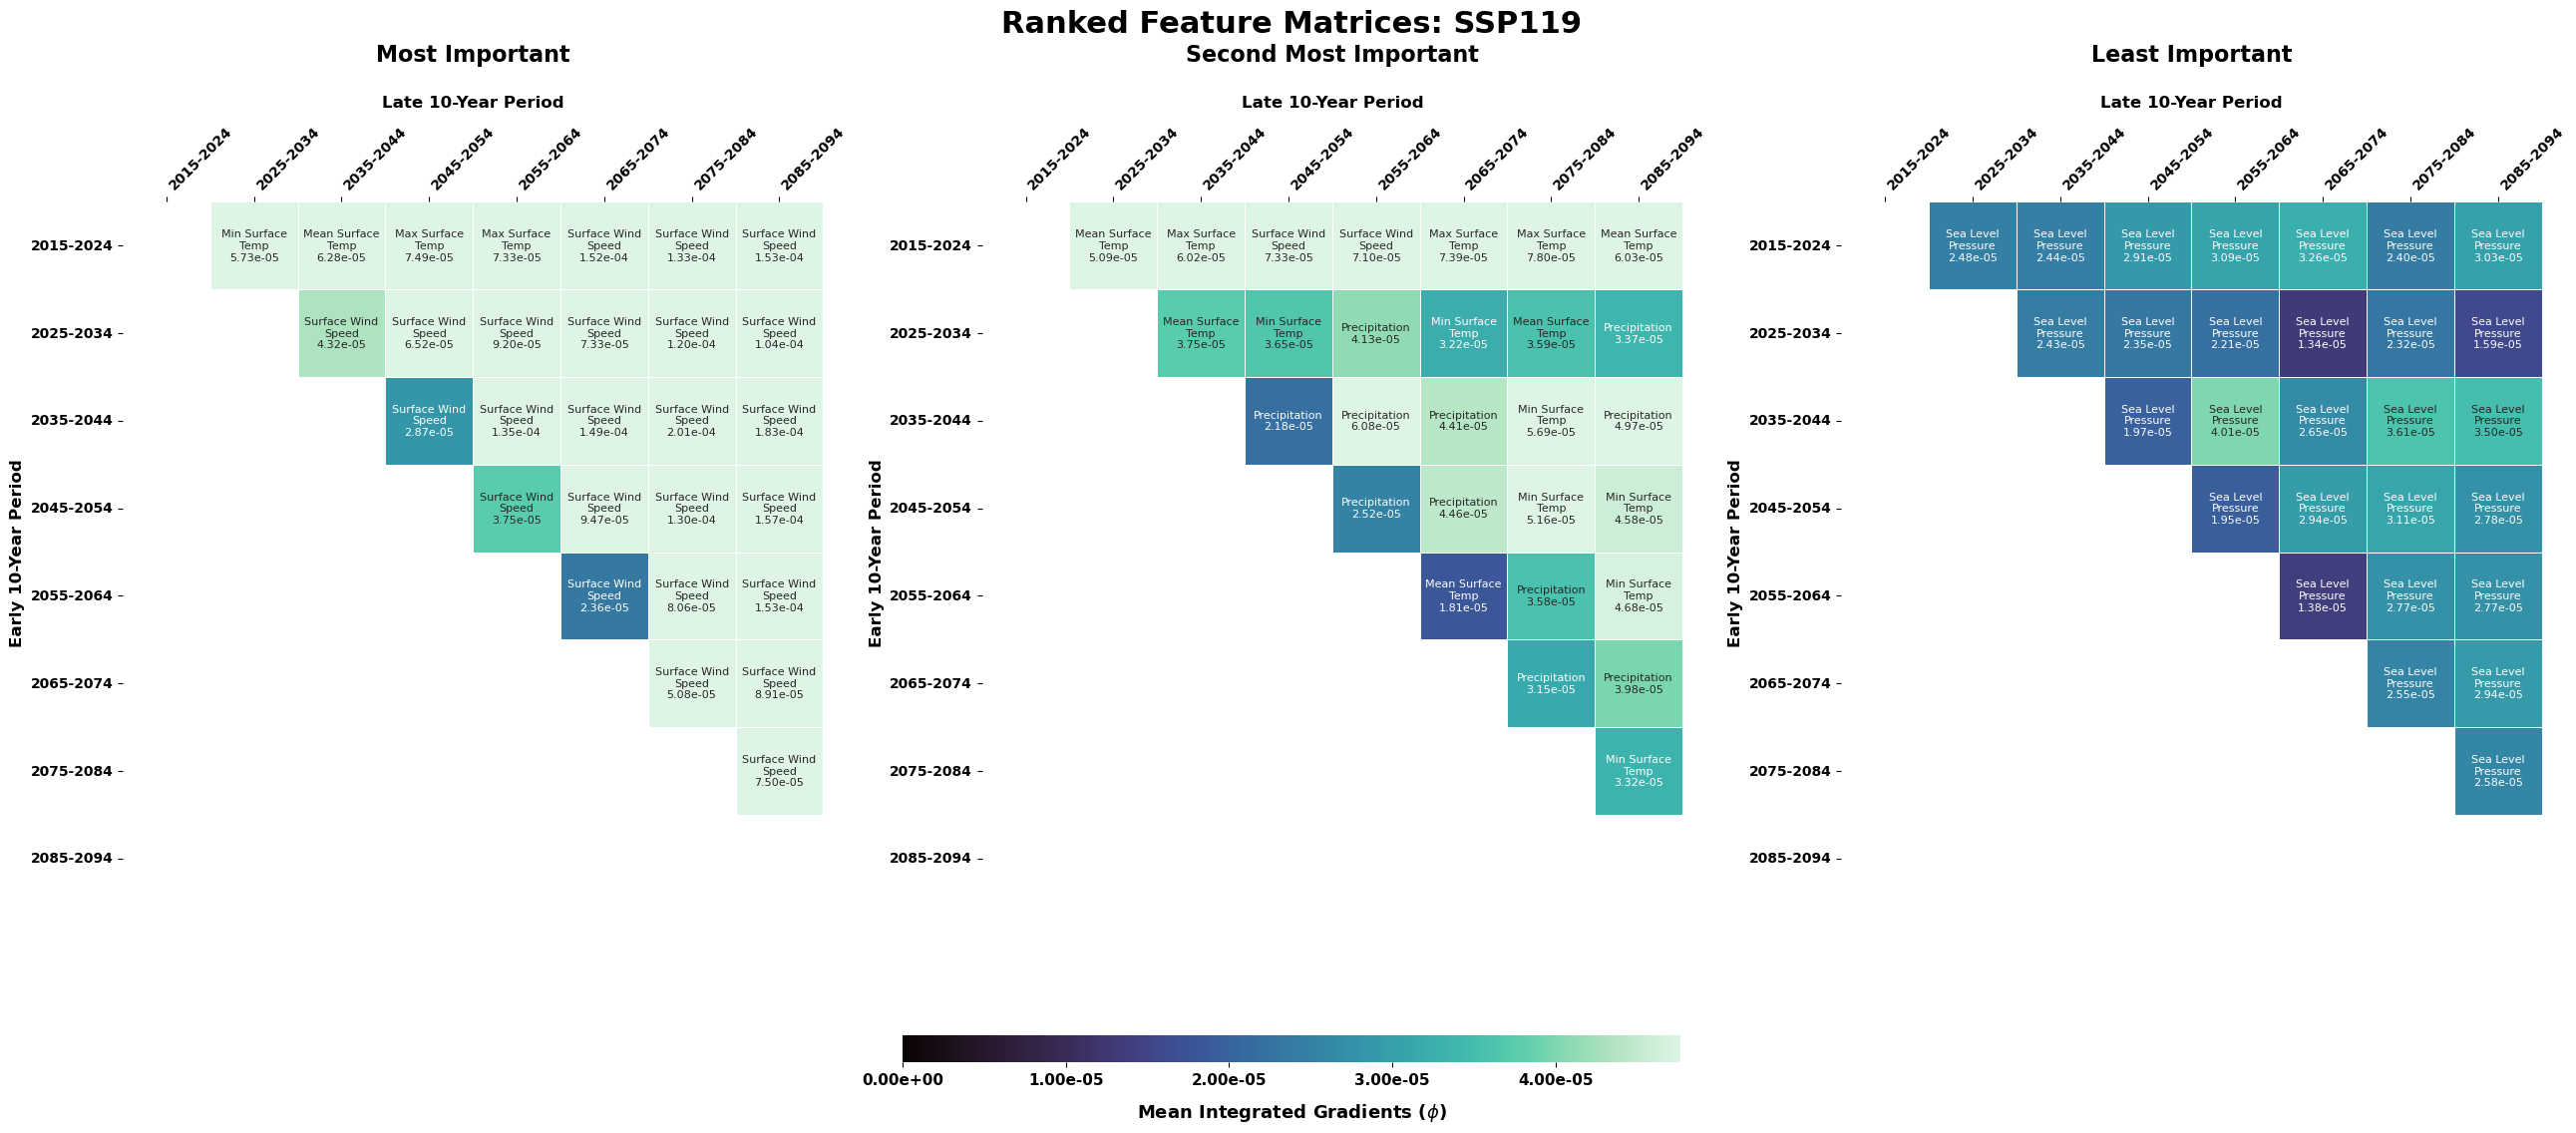

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_31627/3291906729.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])


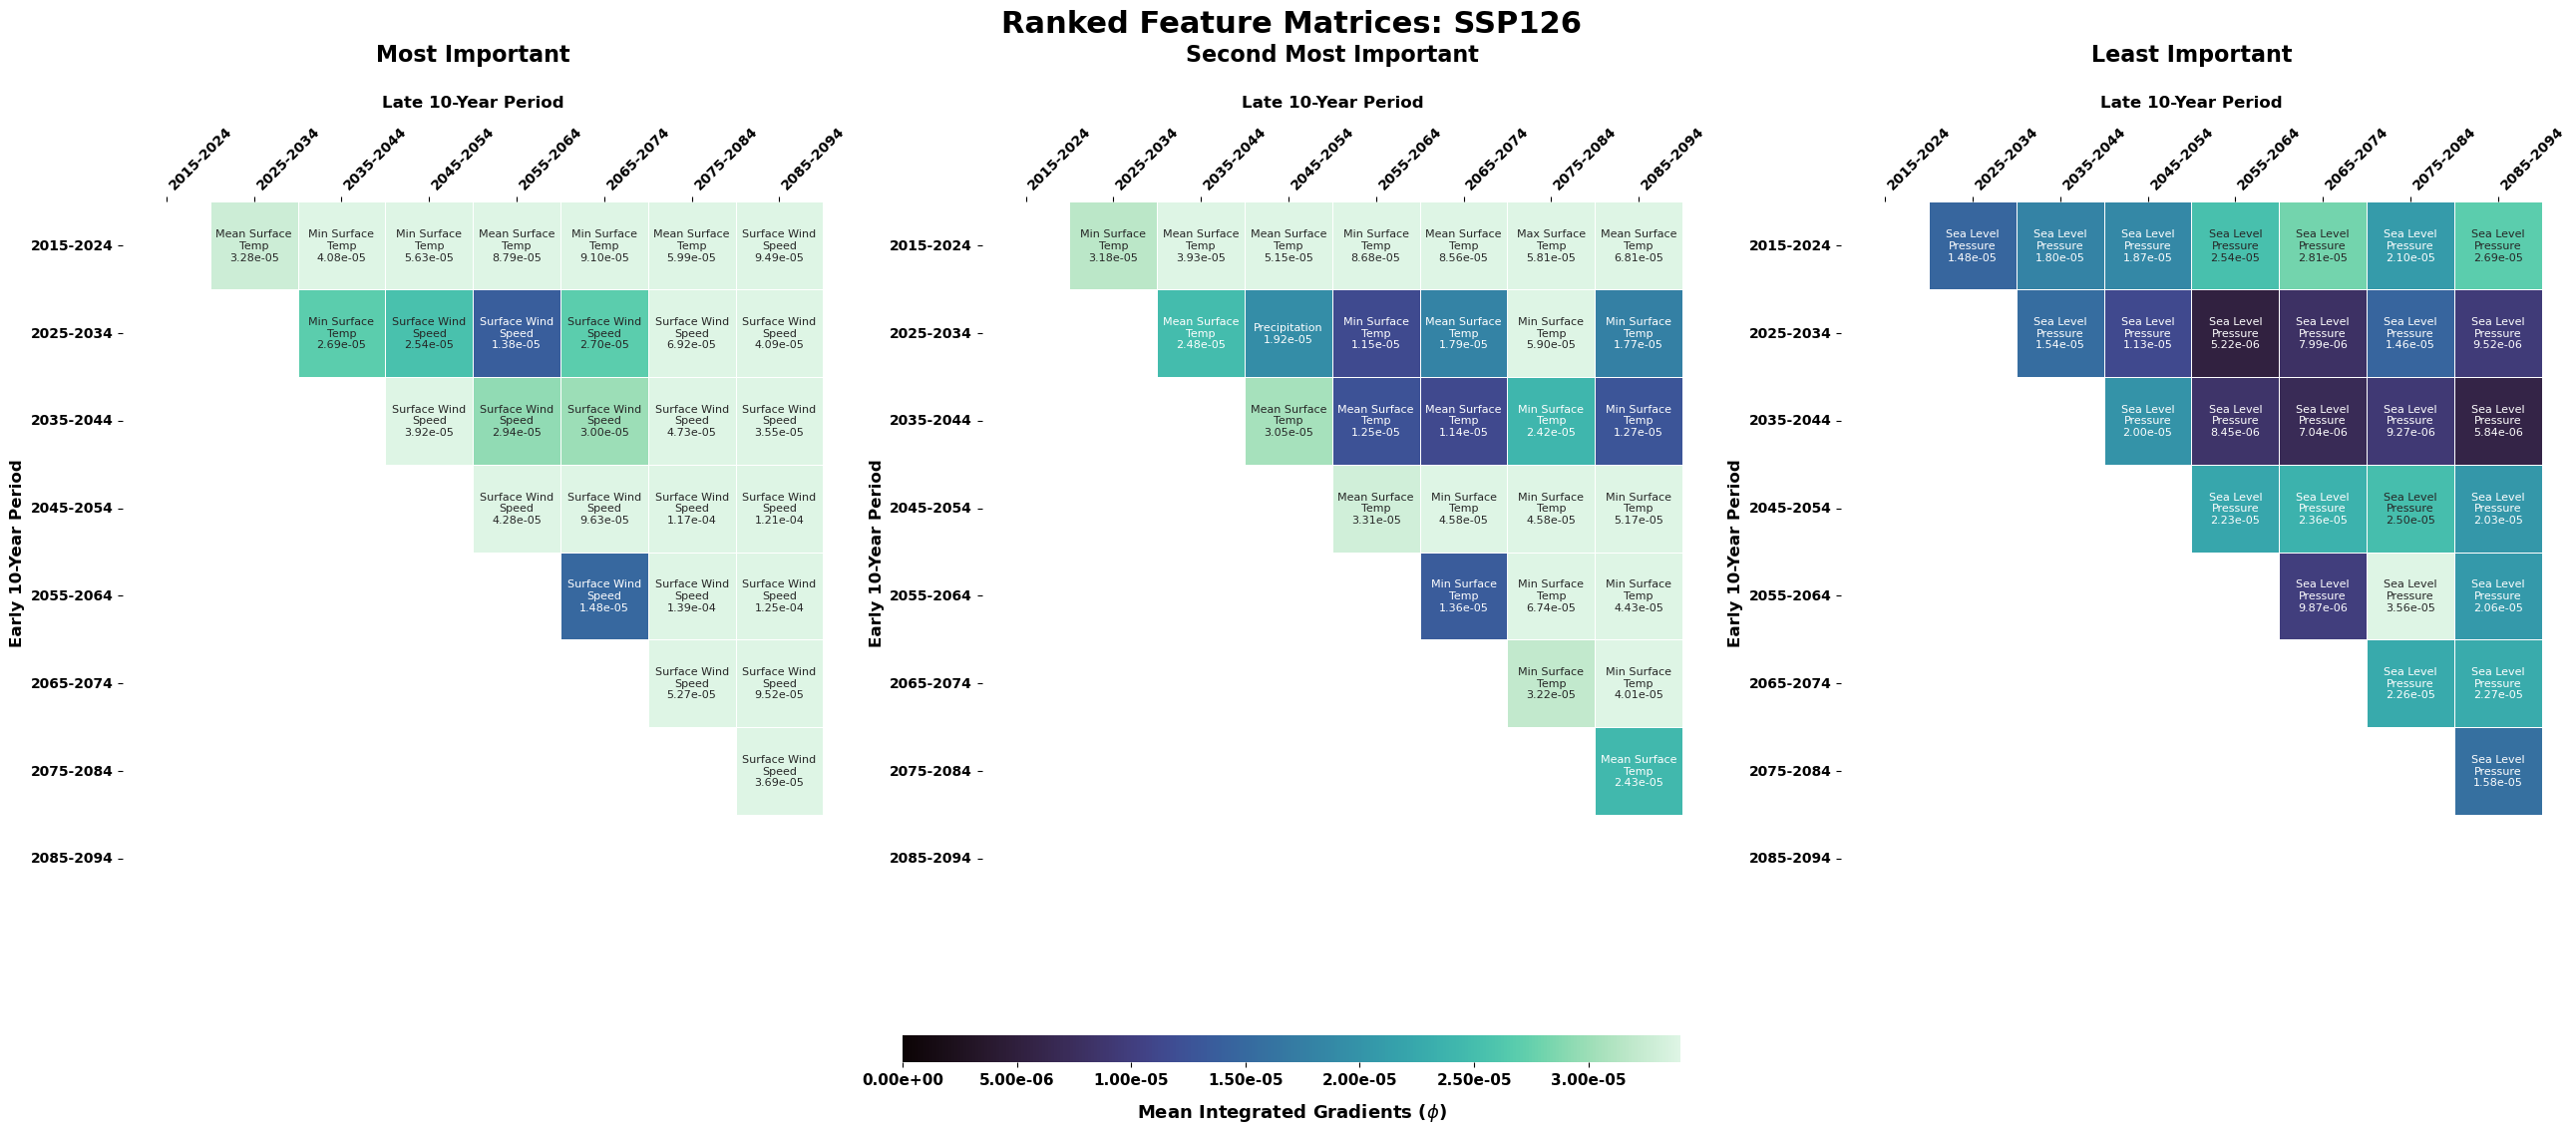

In [ ]:

# pulling unique scenario values
unique_scenarios = metadata_df['scenario'].unique()

for current_scenario in unique_scenarios:
    # filter metadata df for that one scenario 
    temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
    
    # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
    temp_matrix = master_phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
    
    # plot
    var_importance_heatmaps_single_colorbar(
        phi_matrix=temp_matrix, 
        metadata_df=temp_df, 
        var_names=readable_variables, 
        scenario_id=current_scenario 
    )

In [ ]:

def var_importance_heatmaps_three_colorbar(phi_matrix, metadata_df, var_names, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 7)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # final averaging for plotting --> averaging across all the batches and long/lat 
        # first dimension = number of result batches, second = year combos, third = long, fourth = lat, fifth = variables
        # leaving behind the yr combos and variables 
    mean_importance = np.nanmean(np.abs(phi_matrix), axis=(0, 2, 3))
    
    # sorting by variable importance values 
        # argsort gives index position
        # sort gives actual values
    sorted_indices = np.argsort(mean_importance, axis=1)
    sorted_values = np.sort(mean_importance, axis=1)
    
     # getting the importance rankings for most important, second most important, least important 
    rank_keys = ["Most Important", "Second Most Important", "Least Important"]
    rank_data = [
        (sorted_indices[:, -1], sorted_values[:, -1]), # most important (last)
        (sorted_indices[:, -2], sorted_values[:, -2]), # 2nd most important (2nd to last)
        (sorted_indices[:, 0],  sorted_values[:, 0])   # least important (first)
    ]
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(metadata_df['early'].unique()) | set(metadata_df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    


   # PLOTTING NOW
    # 1 row and 3 plots with specified fig size 
    fig, axes = plt.subplots(1, 3, figsize=(26, 11))
    
    # going thru the rankings
    for i, rank_title in enumerate(rank_keys):
        rank_indices, rank_values = rank_data[i]
         # setting axes index for correct data to be in the corresponding importance heatmap
        ax = axes[i]
        
        # getting min and max values based on the min and maxes for that importance heatmap
        current_vmin = np.nanmin(rank_values)
        current_vmax = np.nanmax(rank_values)
        
         # cell label formatting --> variable name and then next line is the variable importance value in scientific notation rounded to 2 dec places
            # list comprehension
                # zip puts the rank index and rank value tg (rank index is what variable it is and rank value is the IG importance value)
                # var_names[idx] pulls the variable name that corresponds with the rank index and then val for rank value 
        combined_labels = [
            f"{var_names[idx]}\n{val:.2e}" 
            for idx, val in zip(rank_indices, rank_values)
        ]
        
        # attaching the IG importance values and formatted text labels above to the metadata
        df = metadata_df.copy()
        df['importance_val'] = rank_values  
        df['text_label'] = combined_labels  
        
        # pivot table to rows as early yrs and cols are late yrs 
        color_matrix = df.pivot_table(index='early', columns='late', values='importance_val', aggfunc='first')
        # reindexing to make matrix include every early and late yr combos
        color_matrix = color_matrix.reindex(index=all_years, columns=all_years)
        
        # doing same thing as above but with the text labels 
        text_matrix = df.pivot_table(index='early', columns='late', values='text_label', aggfunc='first')
        text_matrix = text_matrix.reindex(index=all_years, columns=all_years).fillna("")
        
        # lower triangle mask 
        mask = np.tril(np.ones_like(color_matrix, dtype=bool), k=0)
        
        sns.heatmap(
            color_matrix,
            mask=mask,
            cmap='mako', 
            annot=text_matrix.values, 
            fmt="",                   
            square=True,
            linewidths=.5,
            vmin=current_vmin, # gives colorbar value of minimum value of that importance variable ranking 
            vmax=current_vmax, # same for min value of colorbar
            ax=ax,
            annot_kws={"size": 8}, # text size of cell text 
            cbar_kws={ # colorbar orientation and whatnot
                "orientation": "horizontal", 
                "pad": 0.12,                 
                "shrink": 0.85 
            } 
        )
        
        colorbar = ax.collections[0].colorbar # grabbing colorbar for that specific heatmap
        colorbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2e')) # scentific formatting 
        colorbar.ax.tick_params(labelsize=10)
        for tick in colorbar.ax.get_xticklabels():
            tick.set_fontweight('bold')
            
        colorbar.set_label("Mean IG ($\phi$)", fontsize=10, fontweight='bold', labelpad=5)
        
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
        ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=10, fontweight='bold')
        ax.set_yticklabels(labels, rotation=0, fontsize=10, fontweight='bold')
        
        ax.set_xlabel("Late 10-Year Period", fontsize=11, fontweight='bold', labelpad=12)
        ax.set_ylabel("Early 10-Year Period", fontsize=11, fontweight='bold')
        ax.set_title(rank_title, fontsize=15, fontweight='bold', pad=25)
        
    plt.suptitle(f"Ranked Feature Matrices: {scenario_id.upper()}", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

#### **plotting var importance heatmaps for both scenarios with colorbar for each importance ranking**


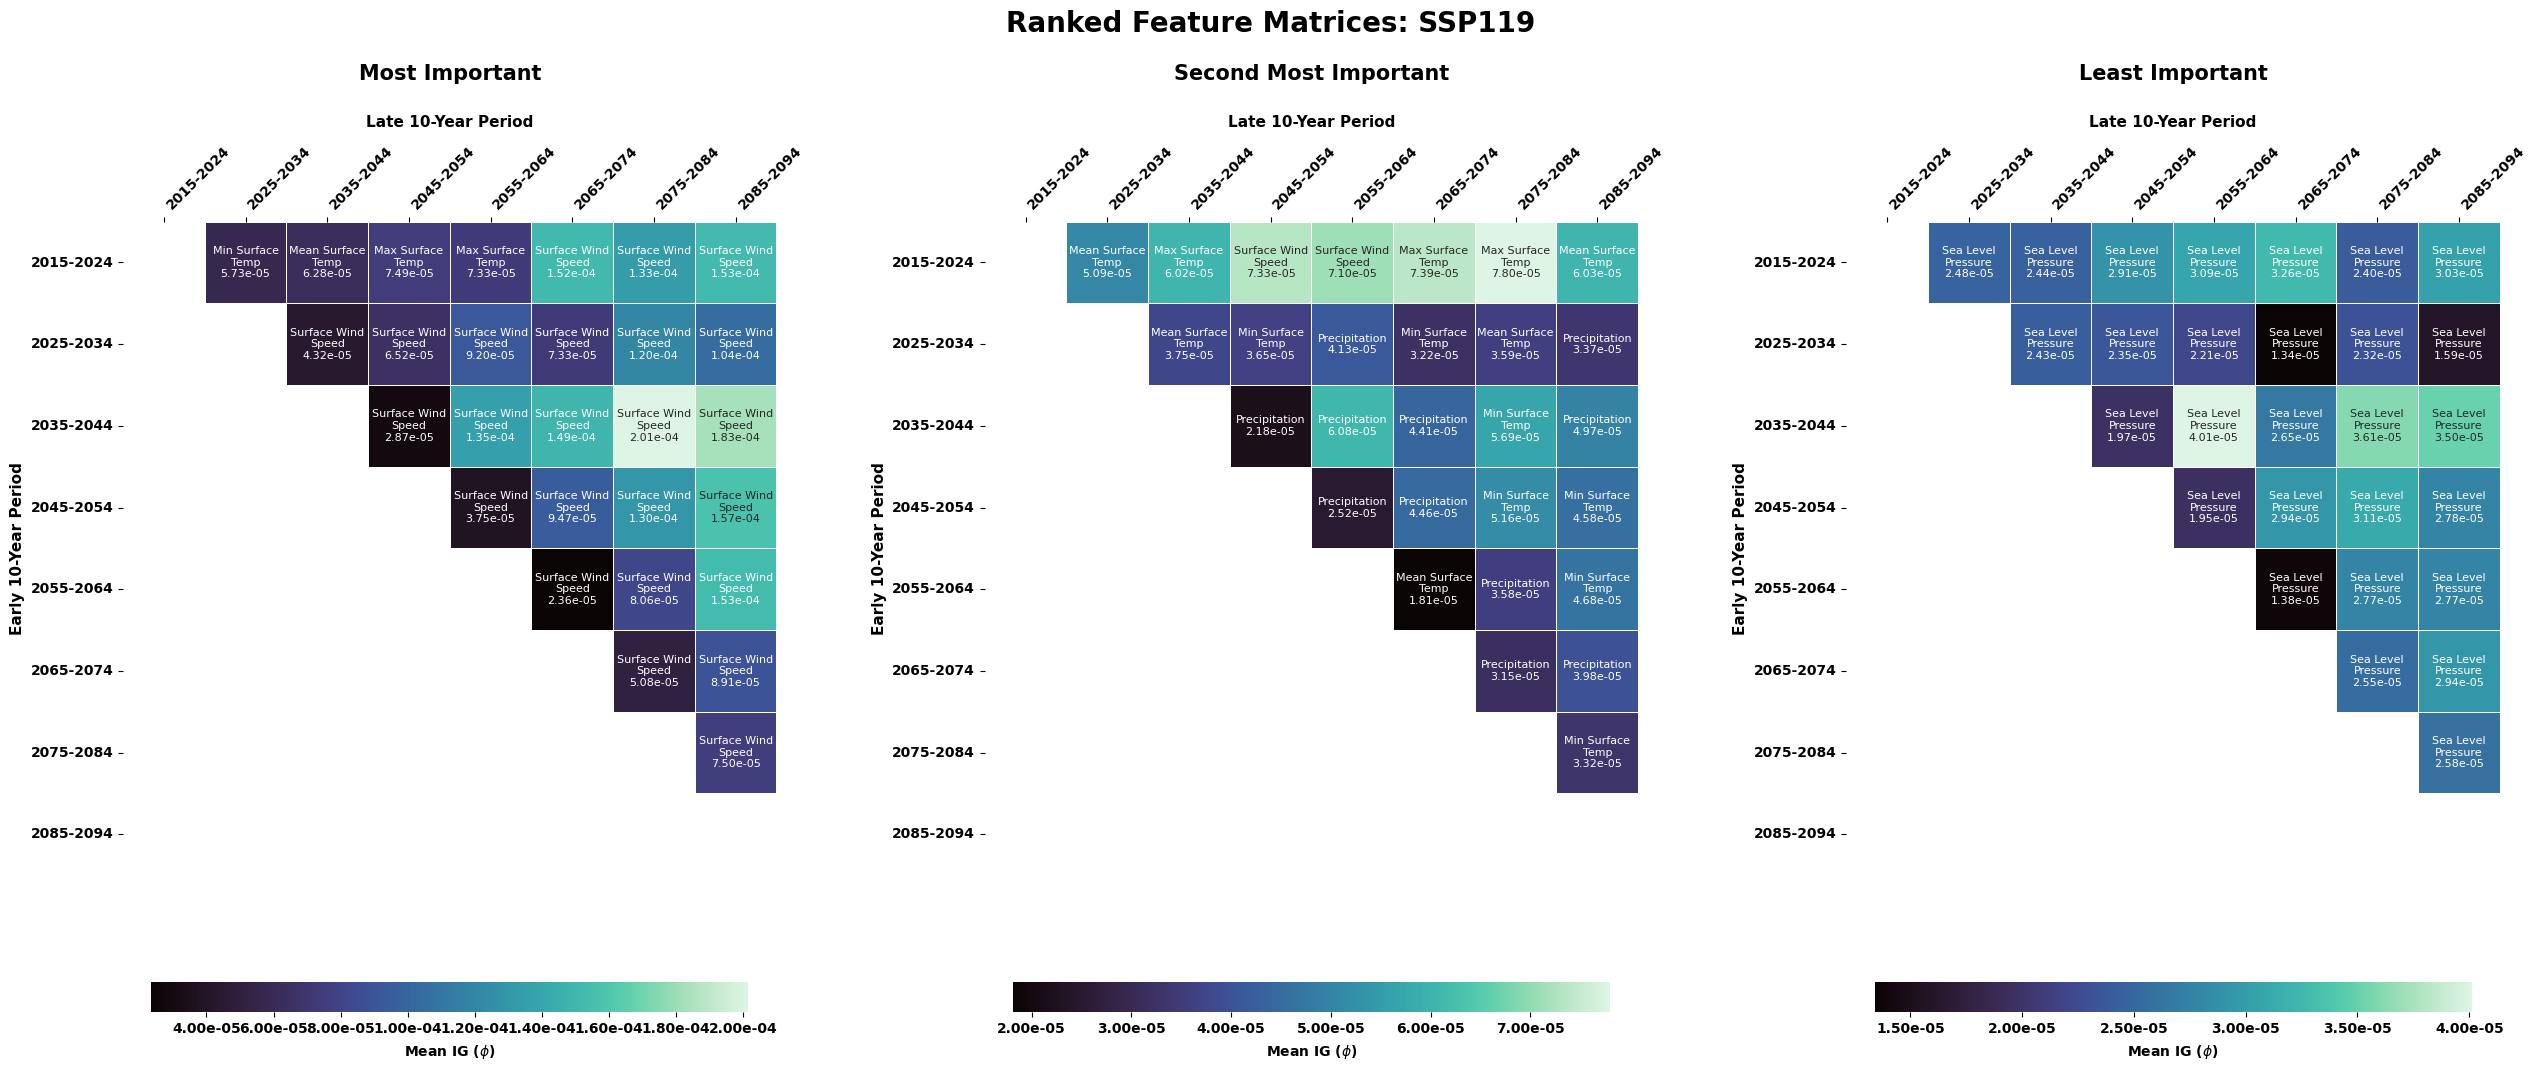

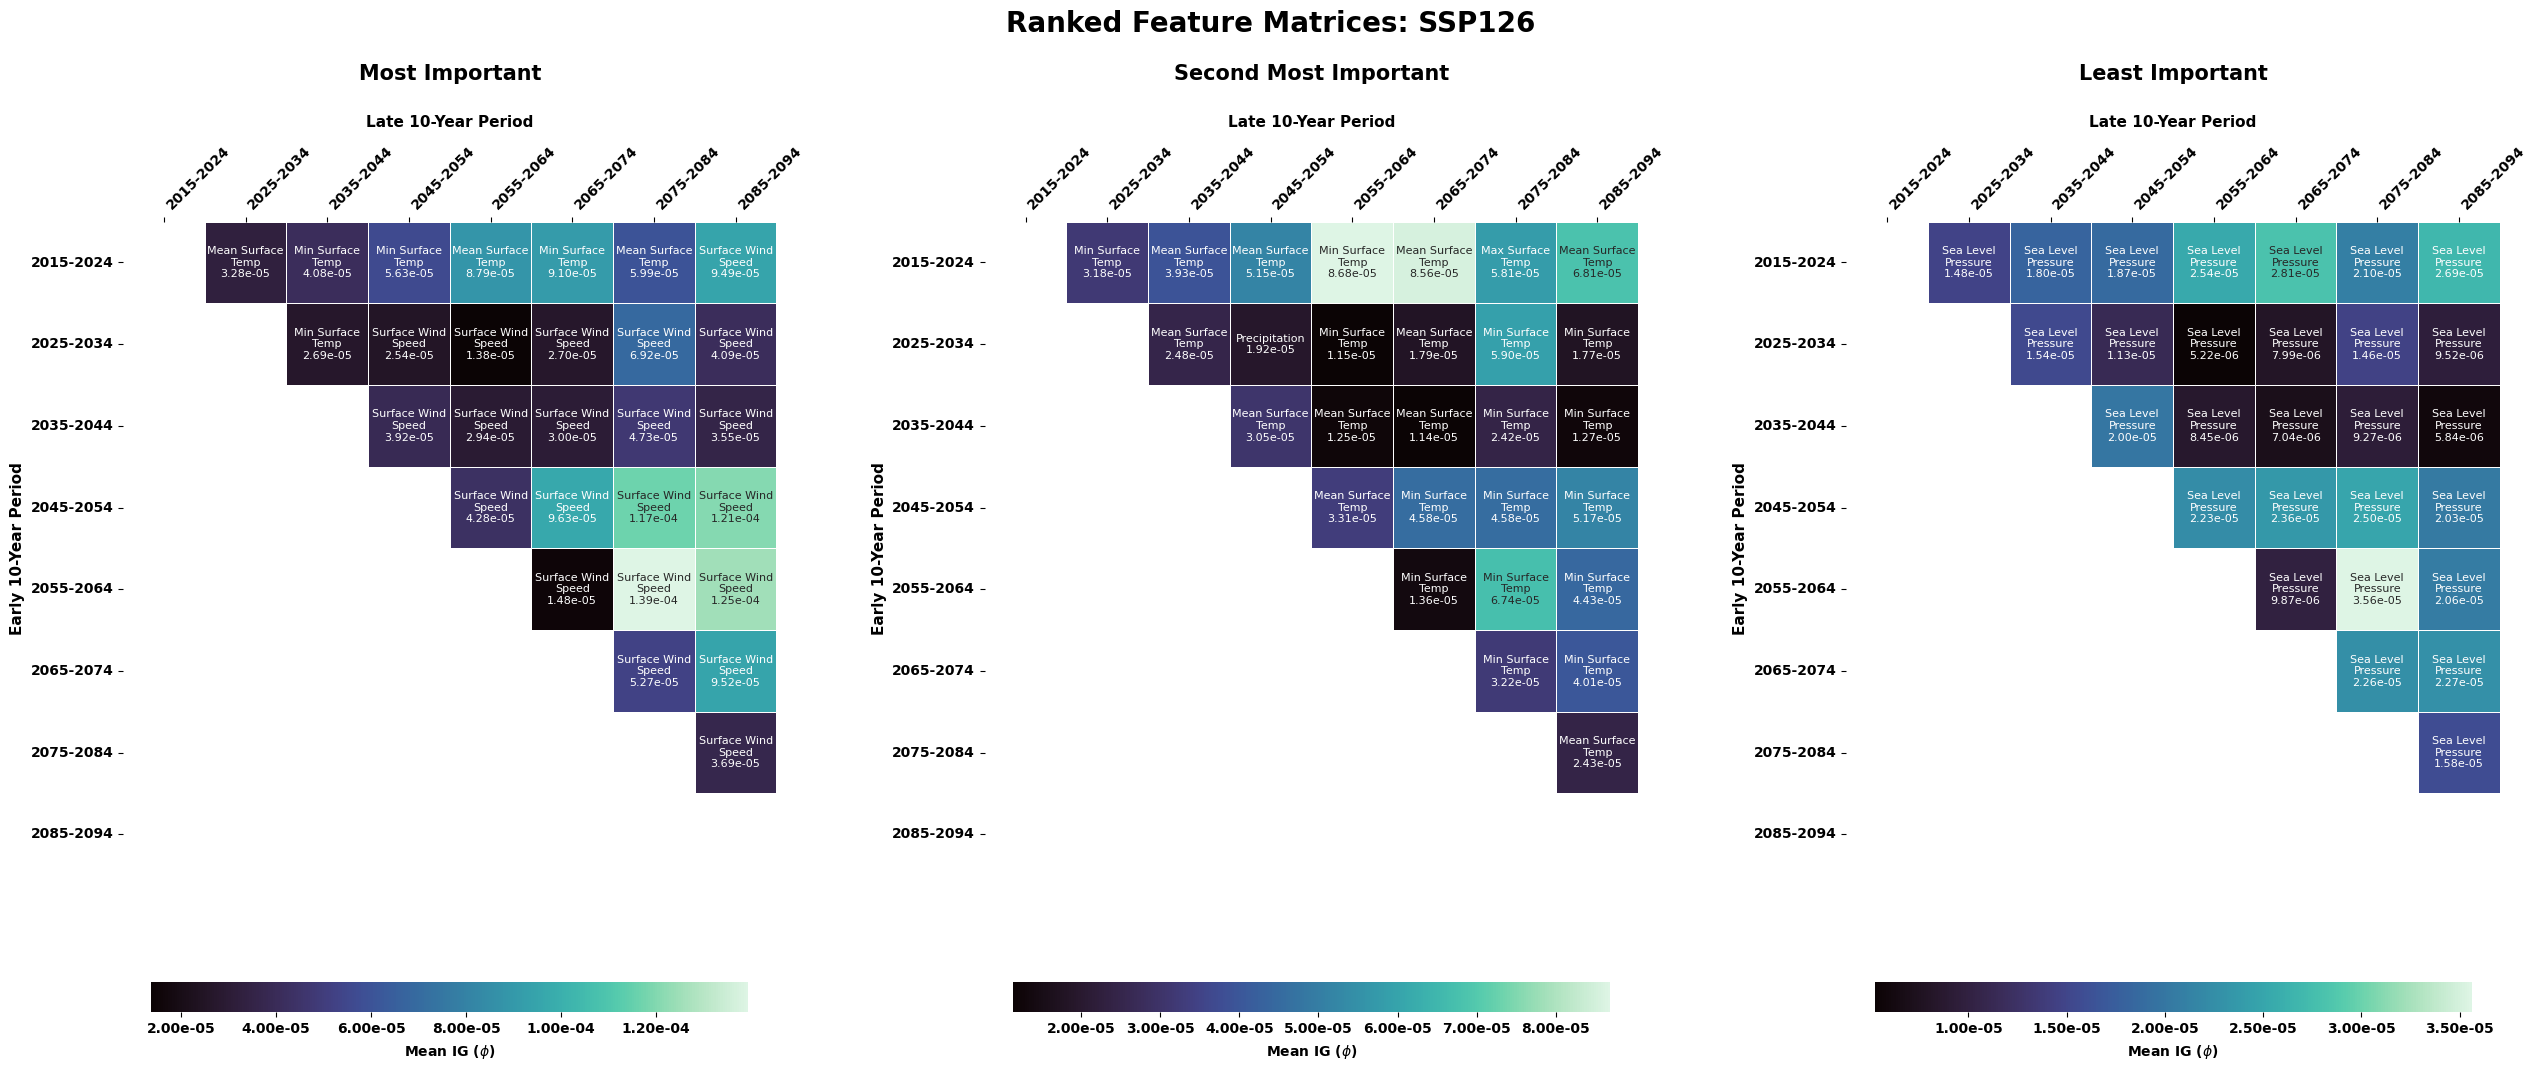

In [ ]:

# pulling unique scenario values
unique_scenarios = metadata_df['scenario'].unique()

for current_scenario in unique_scenarios:
    # filter metadata df for that one scenario 
    temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
    
    # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
    temp_matrix = master_phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
    
    # plot
    var_importance_heatmaps_three_colorbar(
        phi_matrix=temp_matrix, 
        metadata_df=temp_df, 
        var_names=readable_variables, 
        scenario_id=current_scenario 
    )

#### **bar plot to show variable importance for specific yr combo and scenario**

In [ ]:


def plot_single_combo_bar(phi_matrix, metadata_df, early_year, late_year, var_names, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 6)
    metadata_df: df of all the unique yr combos
    var_names: variable names 
    scenario_id: scenario
    """
    
    # look up exact row for requested yr combo in the metadata
    match = metadata_df[(metadata_df['early'] == early_year) & (metadata_df['late'] == late_year)]
    
    # error handling if looking up yr combo that doesn't exist
    if match.empty:
        raise ValueError(f"no combo found for early yr of {early_year} and late yr of {late_year}")
    
    # .iloc[0] gets the specific row and the combo idx gives integer index 
    combo_idx = match.iloc[0]['combo_idx']
    

    # slice phi_matrix for that certain yr combo 
    combo_data = phi_matrix[:, combo_idx, :, :, :] # --> [runs, lat, long, vars]
    

    # averaging across long and lat with absolute values so measuring magnitude of importance 
    spatial_means_per_run = np.nanmean((combo_data), axis=(1, 2))
    
    # convert to dataframe for plotting with col names as the variables 
    df_runs = pd.DataFrame(spatial_means_per_run, columns=var_names)
    # melting so df is two cols: one with climate variable and other with mean var importance
    df_melted = df_runs.melt(var_name='variable', value_name='avg importance')
    

    # grouping melted df by the variable and calculate mean of importances (across the runs) for that variable then sort it in descending order 
    mean_order = df_melted.groupby('variable')['avg importance'].mean().sort_values(ascending=False)
    # storing variable list in the descending order
    order = mean_order.index
    
    # PLOTTING BAR PLOT
    plt.figure(figsize=(12, 7))
    

    ax = sns.barplot(
        data=df_melted,
        x='variable',
        y='avg importance',
        order=order,
        palette='mako',
        
        errorbar=None  # no standard deviation error bars
    )
   # ax.set_yscale("log") # log so that bars are more visible since most important variable lots more important than the other vars
    

    max_val = mean_order.max() # finding highest variable imoprtance bar 
    # buffer = max_val * 0.03 # buffer for text labels so they look uniform 
    min_val = mean_order.min()
    
    # loop thru the sorted descending variable list 
    for i, var in enumerate(order):
        val = mean_order[var]
       # defining position for var importance value to show up above the bar 
        y_pos = val * 1
        ax.text(i, y_pos,
                f"{val:.2e}",
                ha='center', va='bottom', fontweight='bold', fontsize=10)
   
    
    # formatting stuff 
    plt.title(f"Variable Importance ({early_year} vs {late_year}) - {scenario_id.upper()}", 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel("Climate Variables", fontsize=13, fontweight='bold', labelpad=15)
    plt.ylabel("Mean Integrated Gradients ($\phi$)", fontsize=13, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=12, fontweight='bold')
    

    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e')) # y axis as scientific notation 
    plt.yticks(fontsize=11, fontweight='bold')
    

    plt.ylim(min_val * 1.15, max_val * 1.15) # scale y axis max value based on the highest bar
    
    plt.show()

#### **bar plot of var importance for specific yr combo for both scenarios**


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_31627/2046503925.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


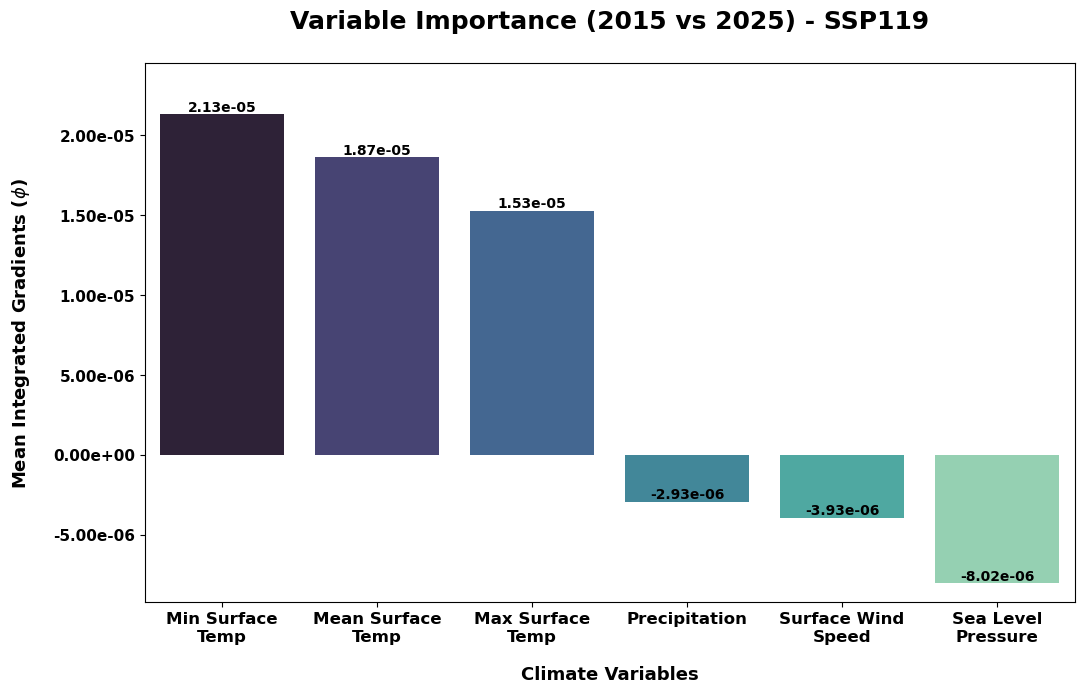

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_31627/2046503925.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


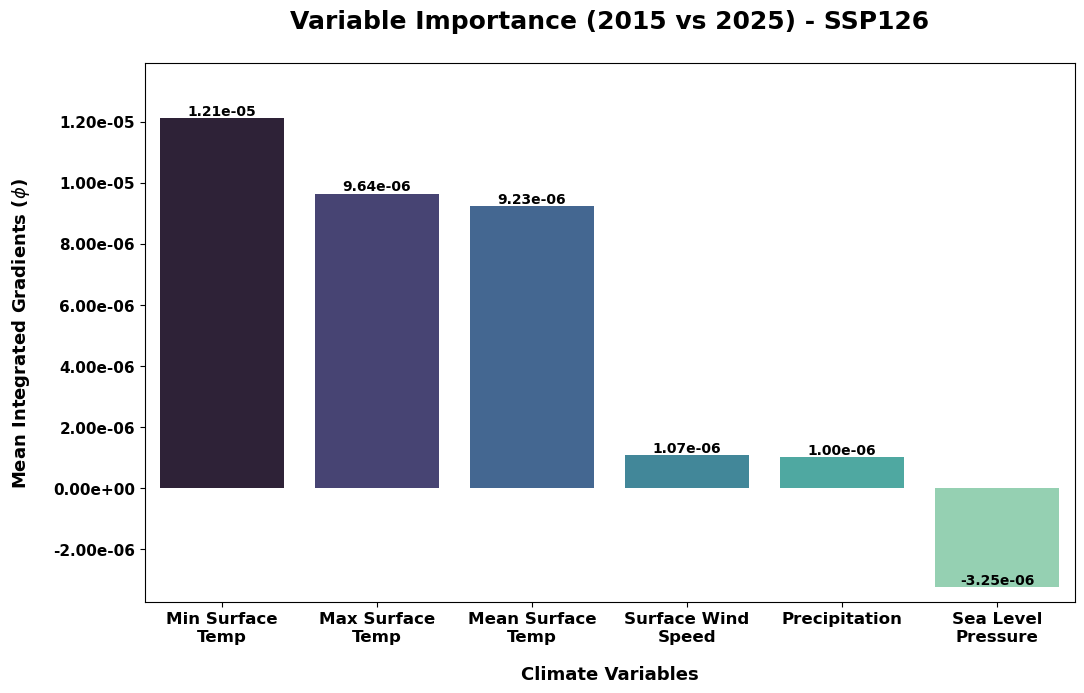

In [ ]:

# pulling unique scenario values
unique_scenarios = metadata_df['scenario'].unique()

for current_scenario in unique_scenarios:
    # filter metadata df for that one scenario 
    temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
    
    # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
    temp_matrix = master_phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
    
    # reset indices in df to match smaller matrix of the one scenario so only the early and late yrs are from that one scenario 
    temp_df['combo_idx'] = range(len(temp_df))
    
    # plot
    plot_single_combo_bar(
        phi_matrix=temp_matrix, 
        metadata_df=temp_df, 
        early_year=2015,       
        late_year=2025,         
        var_names=readable_variables, 
        scenario_id=current_scenario 
    )

### **suplplementary figures**

for comparing total sum of importance values (not magnitude aka sum of phi) with attribution accuracy 

attribution accuracy = did XAI accurately capture what the model is trying to say? --> F(x) - F(x')


***need baseline prediction values for all the model runs***

##### **calculating prediction delta values**

In [ ]:
# initialize delta list 
delta_results = []

for filepath in sorted(list(sample_folder.glob("*.nc"))):
    ds = xr.open_dataset(filepath)

    # extracting preds and baseline preds 
    y_preds = ds['y_pred'].values 
    baseline_preds = ds['exact_baseline_prediction'].values
    # averaging difference between the two 
    combo_mean_delta = np.nanmean(y_preds - baseline_preds)
    
    # extracting early, late and scenario for better merging
    early = int(ds['early_yr'].values)
    late = int(ds['late_yr'].values)
    scenario = str(ds['scenario'].values)
    

    delta_results.append({
        'early': early,
        'late': late,
        'scenario': scenario,
        'mean_pred_delta': combo_mean_delta
    })
    
    ds.close()

# make list into df 
deltas_df = pd.DataFrame(delta_results)

# merge left into metadata df on early/late/scenario
metadata_df = pd.merge(metadata_df, deltas_df, on=['early', 'late', 'scenario'], how='left')

##### **calculating sum of phis**

In [ ]:

sorted_files = sorted(list(sample_folder.glob("*.nc")))

# initialize list 
phi_mapping = []

# calculating phi sum values 
# average across batches 
mean_across_batches = np.nanmean(master_phi_matrix, axis=0)
# sum across globe and variables 
total_phi_sum = np.nansum(mean_across_batches, axis=(1, 2, 3))

# looping through sorted nc files to make sure everything aligned 
for i, filepath in enumerate(sorted_files):
    with xr.open_dataset(filepath) as ds:
        early = int(ds['early_yr'].values)
        late = int(ds['late_yr'].values)
        scenario = str(ds['scenario'].values) 
            
    # mapping the summed value to the scenario/yr combo 
    phi_mapping.append({
        'scenario': scenario,
        'early': early,
        'late': late,
        'completeness_sum': total_phi_sum[i] 
    })

# make into df 
phi_df = pd.DataFrame(phi_mapping)

# merge
metadata_df = pd.merge(
    metadata_df, 
    phi_df, 
    on=['scenario', 'early', 'late'], 
    how='left'
)

In [ ]:


def plot_combined_validation_matrices(df, scenario_id="ssp119"):
    """
    phi_matrix: all the averaged heatmaps from the ig layer of nc files --> shape = (10, 56, 144, 73, 6)
    metadata_df: df of all the unique yr combos
    scenario_id: scenario
    """
    
    # getting the unique yr combos
        # pulling out unique early yrs  and unique late yrs 
        # set with the | --> makes set with early and late yr combos and only the unique ones since set does not allow for duplicates
        # sorted --> keeps everything chrnological
    # all_years provides clean sorted integer list 
    all_years = sorted(list(set(df['early'].unique()) | set(df['late'].unique())))
    # list comprehension that gives nice formatting of starting yr and end yr for all yr values in all_years
    labels = [f"{int(y)}-{int(y)+9}" for y in all_years]
    
    # pivot table to rows as early yrs and cols are late yrs and phi sum is values 
    completeness_matrix = df.pivot_table(index='early', columns='late', values='completeness_sum', aggfunc='first')
    # reindexing to make matrix include every early and late yr combos
    completeness_matrix = completeness_matrix.reindex(index=all_years, columns=all_years)
    
    # pivot table to rows as early yrs and cols are late yrs and mean pred delta is values
    attribution_matrix = df.pivot_table(index='early', columns='late', values='mean_pred_delta', aggfunc='first')
    attribution_matrix = attribution_matrix.reindex(index=all_years, columns=all_years)
    
    # lower triangle mask
    mask = np.tril(np.ones_like(completeness_matrix, dtype=bool), k=0)

    
    # 1 row, 2 cols
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    
    # PHI SUM MATRIX 
    sns.heatmap(
        completeness_matrix,
        ax=ax1,
        mask=mask,
        cmap='BuGn', 
        annot=True,                  
        annot_kws={"size": 10, "fontweight": "bold"}, 
        fmt=".2e",                
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8, "label": "Sum of $\phi$ (Net Prediction Delta)"} 
    )
    
    # phi sum colobar formaatting
    cbar1 = ax1.collections[0].colorbar
    cbar1.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    cbar1.ax.tick_params(labelsize=11)
    for tick in cbar1.ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # phi sum axes formatting
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.set_xticklabels(labels, rotation=45, ha='left', fontsize=11, fontweight='bold')
    ax1.set_yticklabels(labels, rotation=0, fontsize=11, fontweight='bold')
    ax1.set_xlabel("Late 10-Year Period", fontsize=13, fontweight='bold', labelpad=15)
    ax1.set_ylabel("Early 10-Year Period", fontsize=13, fontweight='bold')
    ax1.set_title(f"Completeness Validation Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=30)


    # MEAN DELTA PRED MATRIX
    sns.heatmap(
        attribution_matrix,
        ax=ax2,
        mask=mask,
        cmap='BuGn', 
        annot=True,                  
        annot_kws={"size": 10, "fontweight": "bold"}, 
        fmt=".2e",                 
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8, "label": "Mean Prediction Delta: $F(x) - F(x')$"} 
    )
    
    # mean delta pred colorbar formatting
    cbar2 = ax2.collections[0].colorbar
    cbar2.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2e'))
    cbar2.ax.tick_params(labelsize=11)
    for tick in cbar2.ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    # mean delta pred axes formatting
    ax2.xaxis.tick_top()
    ax2.xaxis.set_label_position('top')
    ax2.set_xticklabels(labels, rotation=45, ha='left', fontsize=11, fontweight='bold')
    ax2.set_yticklabels(labels, rotation=0, fontsize=11, fontweight='bold')
    ax2.set_xlabel("Late 10-Year Period", fontsize=13, fontweight='bold', labelpad=15)
    ax2.set_ylabel("Early 10-Year Period", fontsize=13, fontweight='bold')
    ax2.set_title(f"Attribution Accuracy Matrix: {scenario_id.upper()}", fontsize=18, fontweight='bold', pad=30)
    
    plt.tight_layout()
    plt.show()

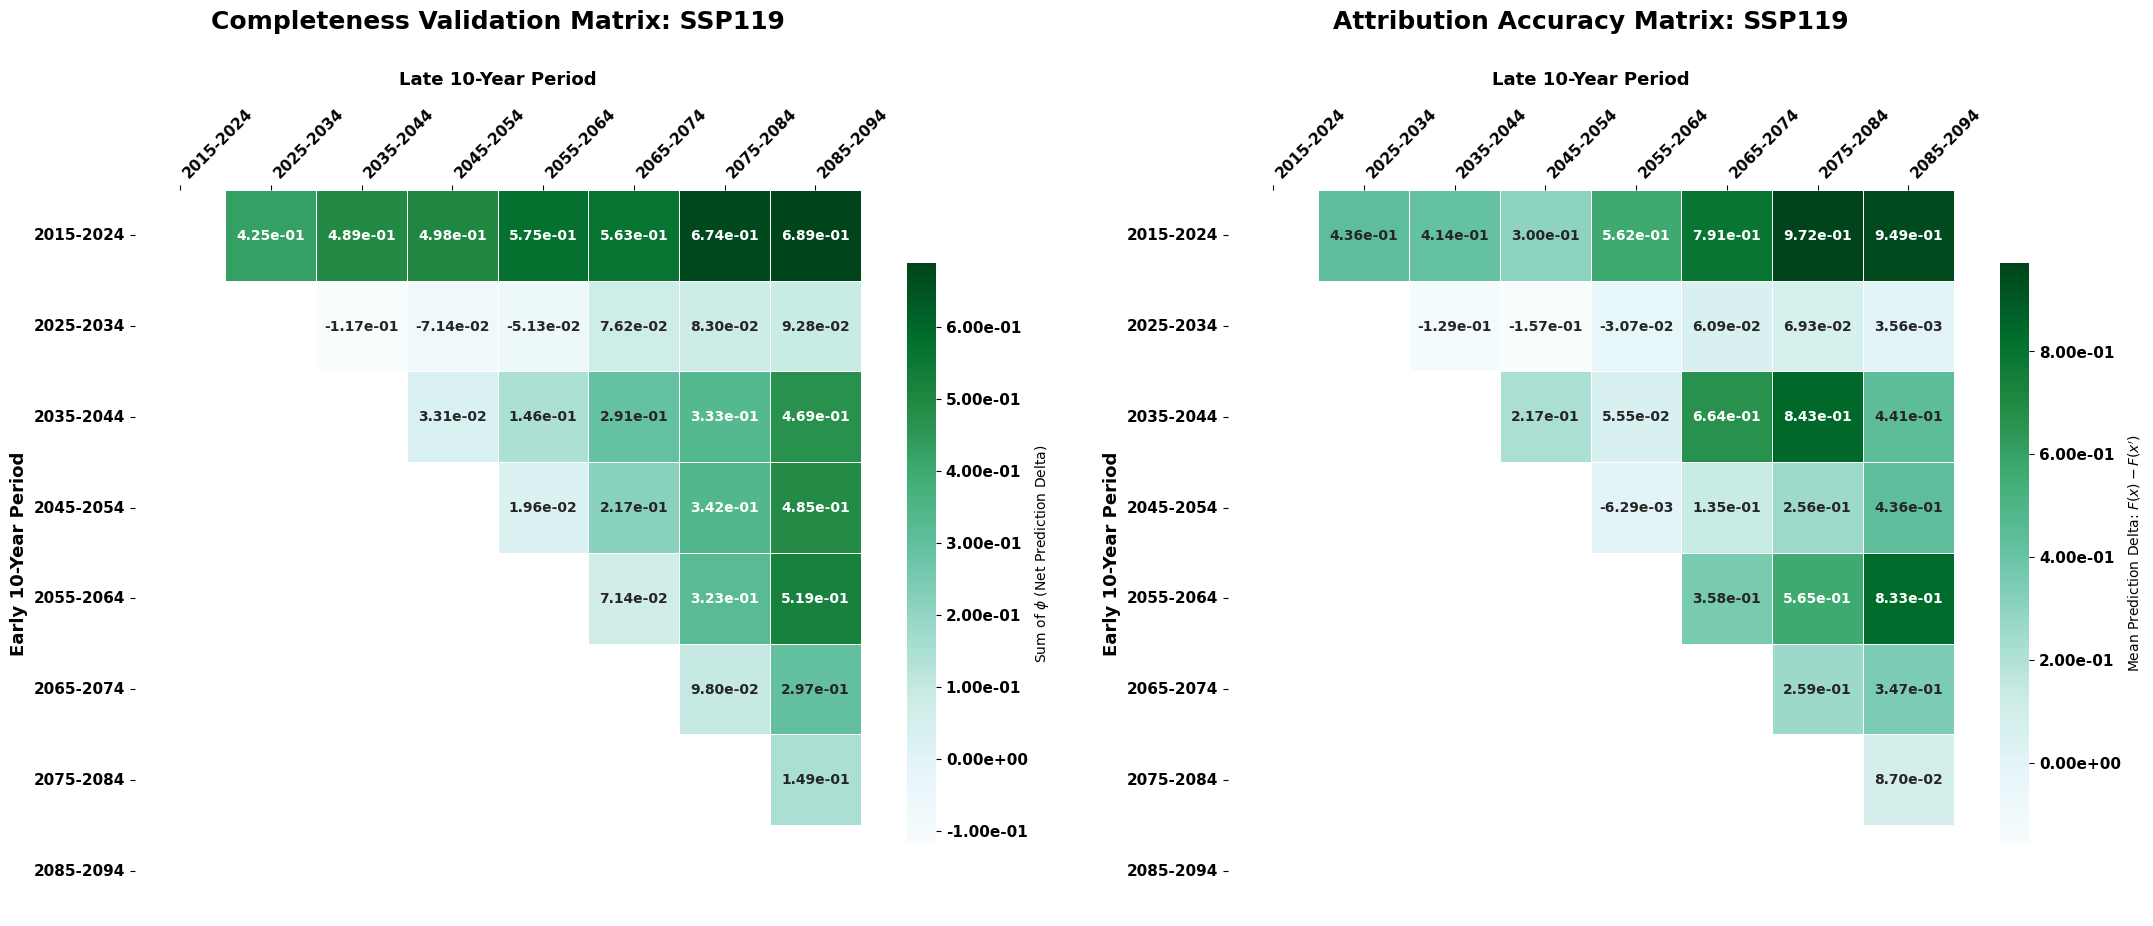

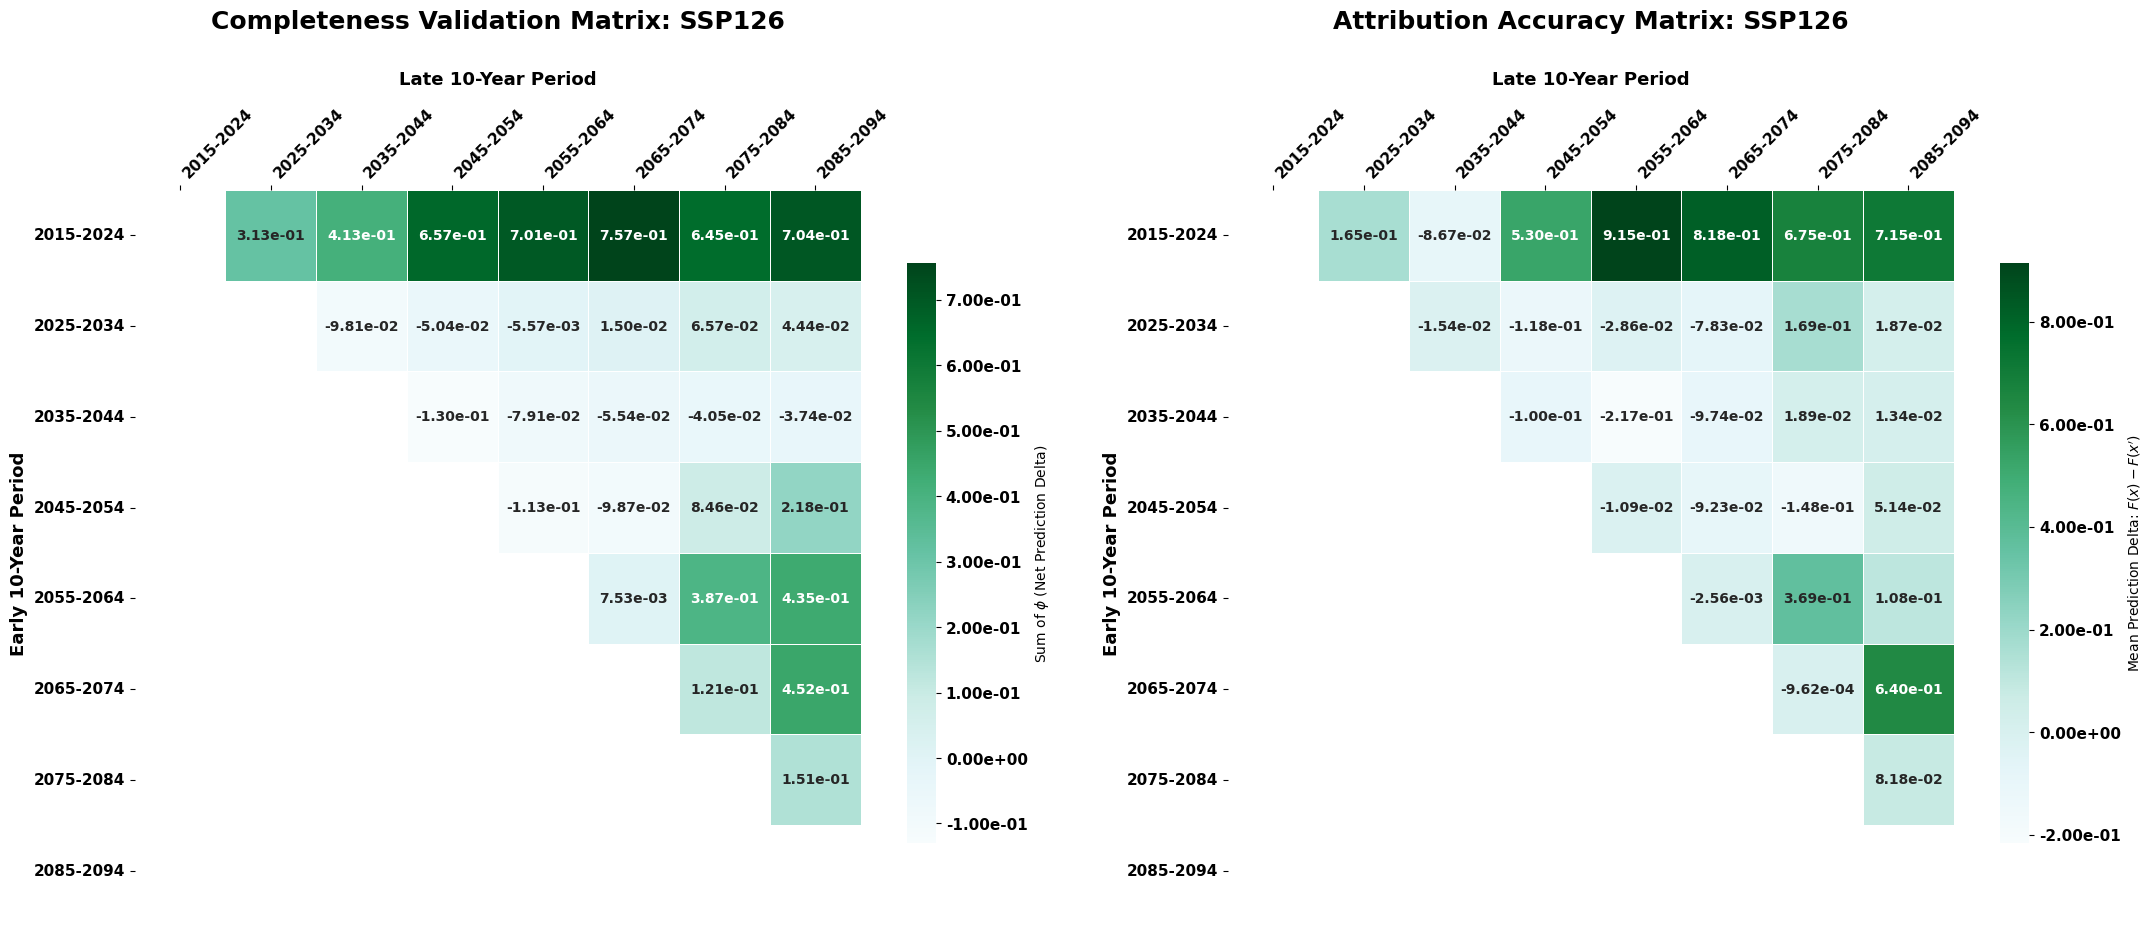

In [ ]:
unique_scenarios = metadata_df['scenario'].unique()

for current_scenario in unique_scenarios:
    # filter metadata df for that one scenario 
    temp_df = metadata_df[metadata_df['scenario'] == current_scenario].copy()
    
    # slice phi matrix calculated above with the yr combo index values that are for that one scenario 
    temp_matrix = master_phi_matrix[:, temp_df['combo_idx'].values, :, :, :]
    
    # reset indices in df to match smaller matrix of the one scenario so only the early and late yrs are from that one scenario 
    temp_df['combo_idx'] = range(len(temp_df))
    
    # plot
    plot_combined_validation_matrices(df=temp_df, 
        scenario_id=current_scenario 
    )

In [ ]:
metadata_df

,combo_idx,scenario,early,late,mean_pred_delta,completeness_sum
0,0,ssp119,2015,2025,0.436482,0.424695
1,1,ssp119,2015,2035,0.413570,0.488884
2,2,ssp119,2015,2045,0.299866,0.498085
3,3,ssp119,2015,2055,0.562446,0.575394
4,4,ssp119,2015,2065,0.791324,0.563113
5,5,ssp119,2015,2075,0.971924,0.673755
6,6,ssp119,2015,2085,0.949490,0.689064
7,7,ssp119,2025,2035,-0.128986,-0.117225
8,8,ssp119,2025,2045,-0.156906,-0.071448
9,9,ssp119,2025,2055,-0.030661,-0.051324


In [ ]:
metadata_df.columns

In [ ]:
metadata_df['ig_error'